<a href="https://colab.research.google.com/github/Bonkerzz2603/TH_deaplearn/blob/main/NguyenGiaKhang_THDeepLearn_tuan3_b4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split

lfw_people = fetch_lfw_people(min_faces_per_person=20, resize=0.5)

X = lfw_people.images
y = lfw_people.target

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print(f"(x_train): {x_train.shape}")
print(f"(x_test): {x_test.shape}")

(x_train): (2267, 62, 47)
(x_test): (756, 62, 47)


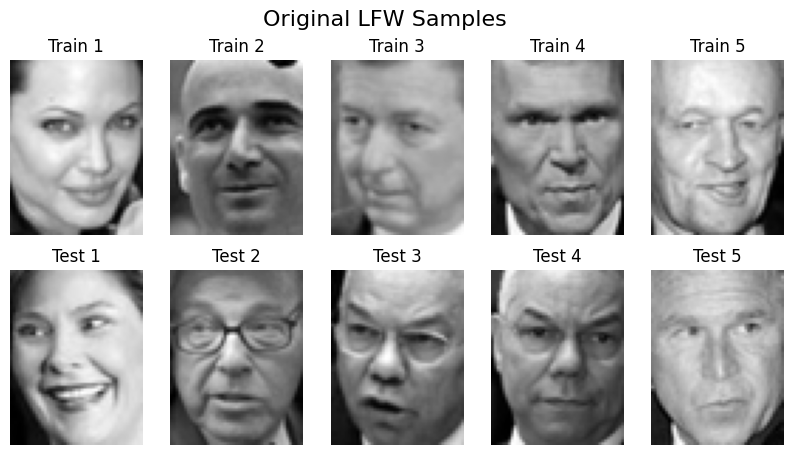

In [34]:
n_samples = 5
plt.figure(figsize=(10, 5))
for i in range(n_samples):
    # Display original training images
    ax = plt.subplot(2, n_samples, i + 1)
    plt.imshow(x_train[i], cmap='gray') # LFW images are often grayscale
    plt.title(f"Train {i+1}")
    plt.axis('off')

    # Display original test images
    ax = plt.subplot(2, n_samples, i + 1 + n_samples)
    plt.imshow(x_test[i], cmap='gray') # LFW images are often grayscale
    plt.title(f"Test {i+1}")
    plt.axis('off')
plt.suptitle('Original LFW Samples', fontsize=16)
plt.show()

In [35]:

# 2. Autoencoder
input_img = layers.Input(shape=(62, 47, 1)) # Changed input shape to match LFW image dimensions

# Encoder
x = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(input_img)
x = layers.MaxPooling2D((2, 2), padding='same')(x)
x = layers.Conv2D(8, (3, 3), activation='relu', padding='same')(x)
encoded = layers.MaxPooling2D((2, 2), padding='same')(x)

# Decoder
x = layers.Conv2DTranspose(8, (3, 3), strides=2, activation='relu', padding='same')(encoded)
x = layers.Conv2DTranspose(16, (3, 3), strides=2, activation='relu', padding='same')(x)
x = layers.Cropping2D(cropping=((1, 1), (0, 1)))(x) # Crop to (62, 47) from (64, 48)
output_img = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

autoencoder_lfw = models.Model(input_img, output_img)
autoencoder_lfw.compile(optimizer='adam', loss='binary_crossentropy')
autoencoder_lfw.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 62, 47, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 62, 47, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 31, 24, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 31, 24, 8)      │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 16, 12, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_6              │ (None, 32, 24, 8)      │           584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_7              │ (None, 64, 48, 16)     │         1,168 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cropping2d_1 (Cropping2D)       │ (None, 62, 47, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 62, 47, 1)      │           145 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,217 (12.57 KB)

 Trainable params: 3,217 (12.57 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
x_train_reshaped = x_train.reshape(x_train.shape[0], x_train.shape[1], x_train.shape[2], 1)
x_test_reshaped = x_test.reshape(x_test.shape[0], x_test.shape[1], x_test.shape[2], 1)

autoencoder_lfw.compile(optimizer='adam',loss='binary_crossentropy', metrics=['accuracy'])
history = autoencoder_lfw.fit(
    x_train_reshaped, x_train_reshaped, # Use reshaped data for training
    epochs=5,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_reshaped, x_test_reshaped) # Use reshaped data for validation
)

Epoch 1/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 15s 769ms/step - accuracy: 5.8280e-05 - loss: 0.6866 - val_accuracy: 8.4885e-05 - val_loss: 0.6813
Epoch 2/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 20s 722ms/step - accuracy: 6.1610e-05 - loss: 0.6754 - val_accuracy: 8.5339e-05 - val_loss: 0.6675
Epoch 3/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 21s 794ms/step - accuracy: 6.3275e-05 - loss: 0.6631 - val_accuracy: 8.6701e-05 - val_loss: 0.6593
Epoch 4/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 14s 763ms/step - accuracy: 6.4032e-05 - loss: 0.6577 - val_accuracy: 8.6701e-05 - val_loss: 0.6551
Epoch 5/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 14s 774ms/step - accuracy: 6.4032e-05 - loss: 0.6538 - val_accuracy: 8.6701e-05 - val_loss: 0.6515


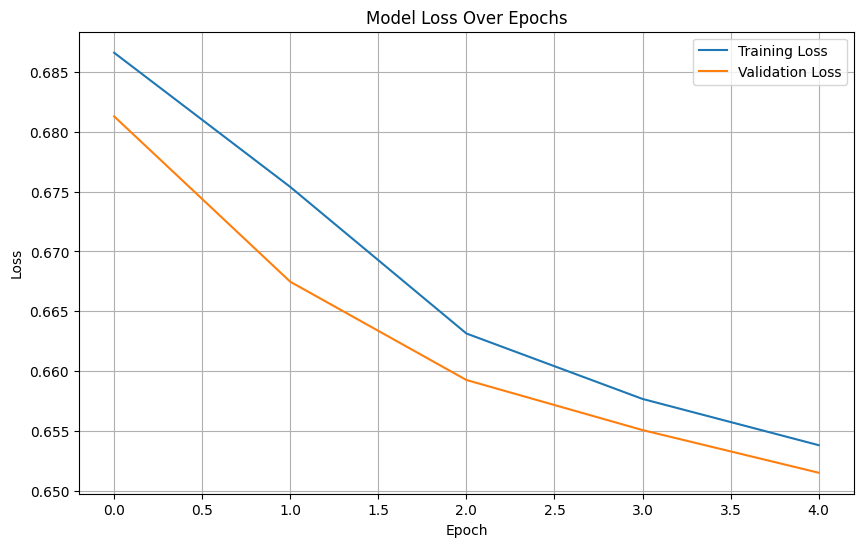

In [38]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step


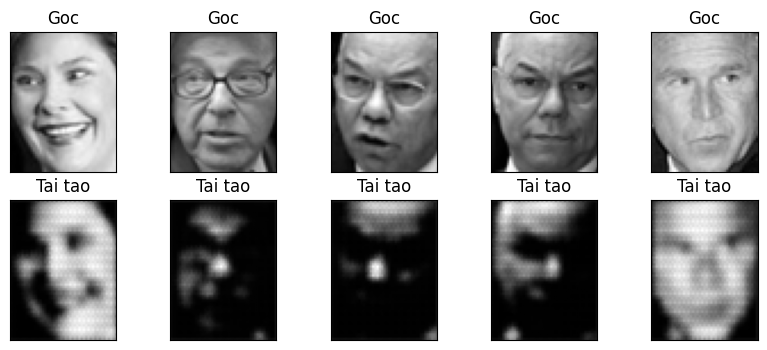

In [39]:
# 4. Truc quan hoa kq
decoded_imgs = autoencoder_lfw.predict(x_test_reshaped) # Corrected model name and using reshaped test data

n = 5
plt.figure(figsize=(10, 4))
for i in range(n):
    # goc
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test_reshaped[i].reshape(62, 47), cmap='gray') # Reshaped to LFW dimensions
    plt.title("Goc")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # sau Autoencoder
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(62, 47), cmap='gray') # Reshaped to LFW dimensions
    plt.title("Tai tao")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()